### CRITERIA

**Algorithm Implementation — 10%**

At least one algorithm from the course must be implemented without only being a wrapper around a library. For example, if implementing a mixture of Gaussians, you can’t use the scikit-learn implementation, but you can use numpy and torch.

- 10 pts: Algorithm is correctly implemented, produces reasonable outputs on the chosen dataset, and the team can explain implementation choices (e.g., choice of distance metric, number of clusters, regularization). The code matches what's being demoed.
- 8 pts: Implementation is correct but the team struggles to explain one design decision, or there is a minor bug that doesn't affect the demo materially.
- 4 pts: Algorithm is mostly a library call to scikit-learn or equivalent with a thin wrapper; the team cannot explain internals, or outputs are clearly wrong.
- 0 pts: The algorithm is entirely copy-pasted from an external source or repo without understanding.


In [ ]:
# import libraries
import numpy as np
import math
import torch
from torch.distributions import Normal, Independent
import matplotlib.pyplot as plt

### GMM code flow

#### This was really helpful to 'see' which functions related to which.

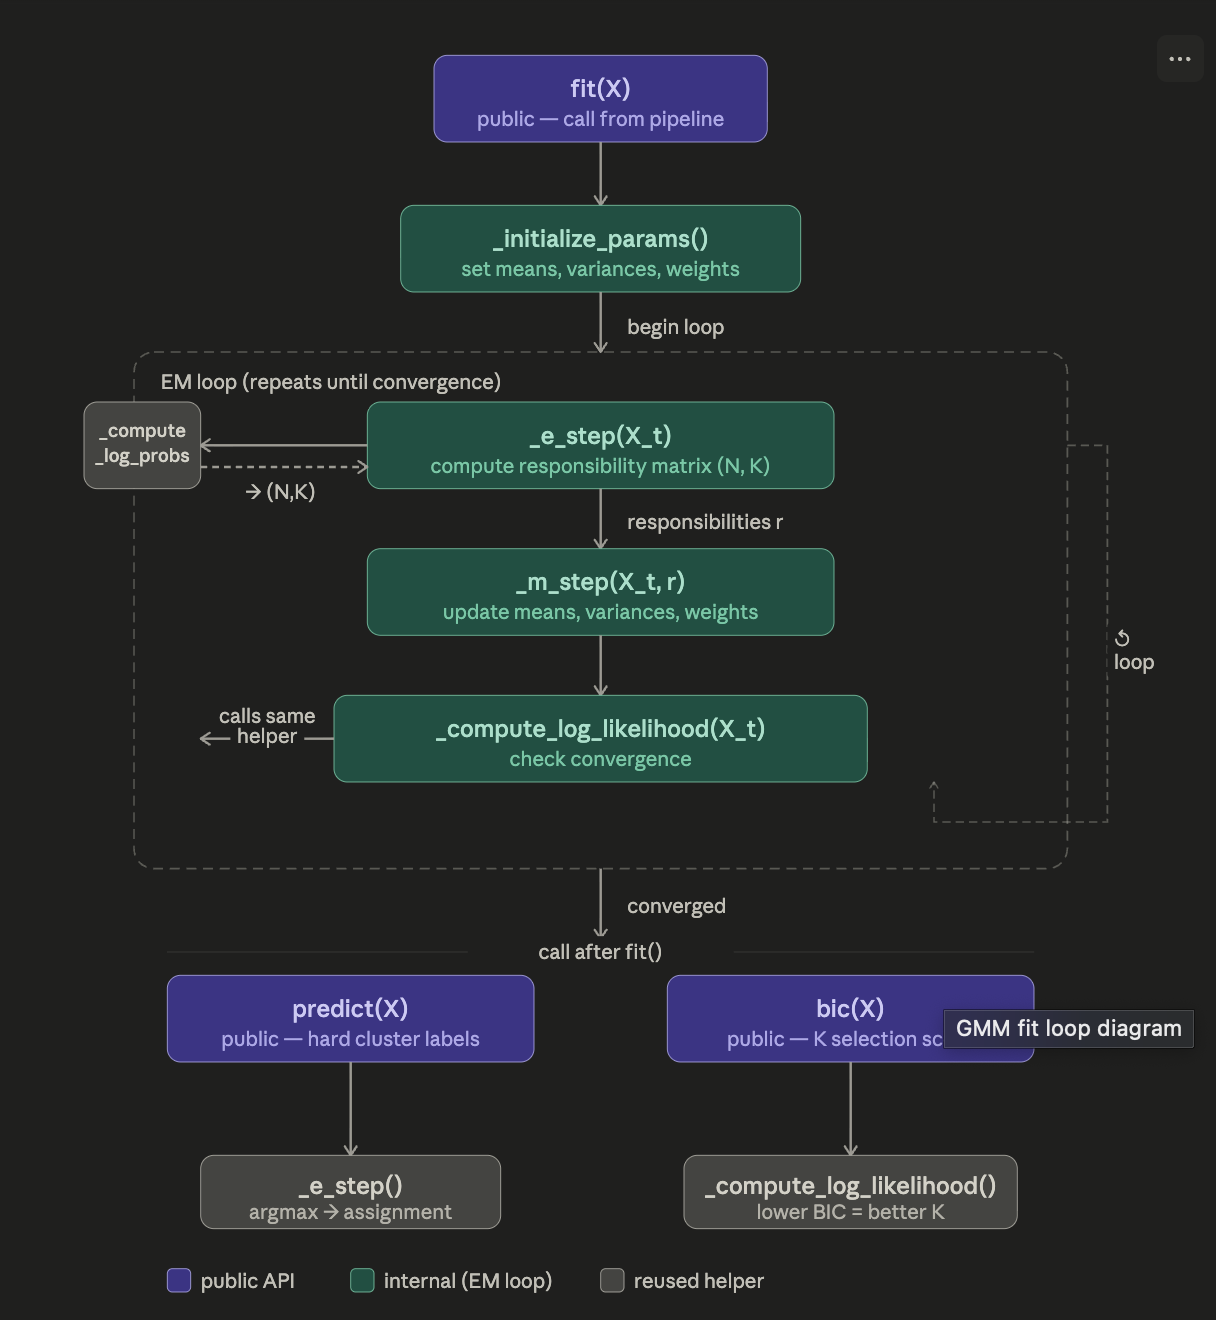

A few things to notice in the diagram:

`_compute_log_probs` is the one function called from two different places — both `_e_step` and `_compute_log_likelihood` need it, which is exactly why it lives in its own helper rather than being inlined. Click any box to ask a follow-up about that specific function.

The dashed loop-back arrow on the right shows the EM iteration — the loop runs `_e_step → _m_step → _compute_log_likelihood` repeatedly, only exiting when the log-likelihood stops improving. Everything below the "converged" arrow only runs once training is complete.

## GMM class

In [ ]:
class GMM:
    def __init__(self, K, max_iter=100, tol=1e-4, min_var=1e-6, device='cpu', seed=67):
      """
      K        : number of clusters
      max_iter : max EM iterations
      tol      : convergence threshold on log-likelihood change
      min_var  : variance floor to prevent cluster collapse
      device   : 'cuda' or 'cpu'
      """
      self.K = K
      self.max_iter = max_iter
      self.tol = tol
      self.min_var = min_var
      self.device = device

      self.seed = seed

      # set during fit()
      self.means = None        # (K, D)
      self.variances = None    # (K, D) — diagonal only, not full matrix
      self.weights = None      # (K,)


    # ------------------------------------------------------------------ #
    #  internal helpers (not called from outside)                        #
    # ------------------------------------------------------------------ #

      # **********

    def _initialize_params(self, X_t):
        """
        Set initial values for means, variances, and weights
        before the EM loop begins.

        Initialize variances to the global variance of X_t along each dim.
        Initialize weights to uniform 1/K.

        Self note: This is like selecting the starter-build for the Gaussian clusters we want to fit onto the data

        Parameters
        ----------
        X_t : torch.Tensor, shape (N, D)
        """
        N, D = X_t.shape

        # ---- apply seed for reproducibility ----
        if self.seed is not None:
            torch.manual_seed(self.seed)
            np.random.seed(self.seed)

        # ---- initialize variances ----
        # use torch to get global variance across all N points, per dim
        #self.variances = torch.var(X_t, dim=0).repeat(self.K, 1)  # (K, D)   ; note: we update the variance in m-step
        self.variances = torch.clamp(torch.var(X_t, dim=0), min=self.min_var).repeat(self.K, 1) # CHANGED/ADDED FOR SAVE FUNCTION

        # ---- initialize means with K-Means++ ----
        # 1) pick first mean randomly from data points
        first_idx = torch.randint(N, (1,)).item()
        chosen_indices = [first_idx]

        # 2) pick each remaining mean
        for _ in range(self.K - 1):
          # stack the already-chosen means -> (num_chosen, D)
          chosen_means = X_t[torch.tensor(chosen_indices, device=self.device)]

          # pairwise distances from every point to every chosen mean -> (N, num_chosen)
          dists = torch.cdist(X_t, chosen_means)

          # for each point, keep only the distance to its nearest chosen mean -> (N,)
          min_dists = dists.min(dim=1).values

          # sampling probability proportional to squared distance
          # far points are more likely to become the next mean
          probs = min_dists ** 2
          probs = probs / probs.sum()   # normalize to valid probability distribution

          # sample one index according to those probabilities
          next_idx = torch.multinomial(probs, num_samples=1).item()
          chosen_indices.append(next_idx)

        # --- means ---
        self.means = X_t[torch.tensor(chosen_indices, device=self.device)]  # (K, D)

        # ---- initialize weights ----
        # literally just makes a torch tensor of ones (like np.ones)
        self.weights = torch.ones(self.K, device=self.device) / self.K  # (K,) ; we do device=self.device because we want to make sure that the code operates on the correct hardware

        # ---- validate ----
        self._validate_params()


    # helper function for debugging ; can be called in m-step if we run into isues
    def _validate_params(self):
        if self.means is None:
            return

        D = self.means.shape[1]  # infer D from means directly

        # sanity checks
        if not torch.allclose(self.weights.sum(), torch.tensor(1.0, device=self.weights.device), atol=1e-4):
          raise ValueError(f"Weights do not sum to 1: {self.weights.sum().item()}")

        if self.means.shape != (self.K, D):
          raise ValueError(f"Means shape incorrect: {self.means.shape}")

        if self.variances.shape != (self.K, D):
          raise ValueError(f"Variances shape incorrect: {self.variances.shape}")

  # **********


    def _compute_log_probs(self, X_t):
        """
        Essentially: For each data point, how likely is it under each Gaussian component?
                     If I assume component k generated this point, how plausible is it?

        Evaluate the diagonal Gaussian log-PDF for every point
        under every cluster. Does NOT include mixing weights.

        Uses Independent(Normal(mean_k, std_k), 1) for each cluster.

        Parameters
        ----------
        X_t : torch.Tensor, shape (N, D)

        Returns
        -------
        log_probs : torch.Tensor, shape (N, K)
        """
        # clamp variances to prevent scale=0 in Normal
        var = torch.clamp(self.variances, min=self.min_var)  # (K, D)
        std = torch.sqrt(var)                                 # (K, D)

        # expand dims for broadcasting — no Python loop needed
        X_exp   = X_t.unsqueeze(1)         # (N, 1, D)
        mu_exp  = self.means.unsqueeze(0)  # (1, K, D)
        std_exp = std.unsqueeze(0)         # (1, K, D)

        # single batched evaluation across all K clusters at once
        dist = Independent(Normal(loc=mu_exp, scale=std_exp), 1)
        return dist.log_prob(X_exp)        # (N, K)
        """
        # input: X_t shape (N, D)
        # output: shape (N, K) — log PDF of each point under each cluster
        # explanation: evaluates the Gaussian PDF for every point under every cluster

        # 0) initialize a list to collect one (N,) vector per cluster
        some_list = []

        # 1) for each cluster k in range(self.k):
        for k in range (self.K):
            # a) build a diagonal Gaussian from self.means[k] and self.variances[k]
            mean_k = self.means[k]
            var_k = self.variances[k]
            var_k = torch.clamp(var_k, min=self.min_var)  # ADDED FOR SAVE FUNCTION
            std_k = torch.sqrt(var_k)

            # selfnote: Independent() bc it tells pytorch to treat all D dimensions as one joint event,
            # so log_prob returns (N,) not (N, D)
            diag_gaussian = Independent(Normal(loc=mean_k, scale=std_k), 1)

            # b) evaluate log_prob for all N points -> (N,)
            log_probs_k = diag_gaussian.log_prob(X_t)  # (N,)

            # c) append to your list
            some_list.append(log_probs_k)

        # 2) stack the list into a single tensor → (N, K), and return
        return torch.stack(some_list, dim=1) # this converts some_list to a proper tensor
        """

    def _e_step(self, X_t):
        """
        Compute log-responsibilities for every point and cluster.

        Calls _compute_log_probs(), adds log mixing weights,
        then normalizes each row using logsumexp.

        Parameters
        ----------
        X_t : torch.Tensor, shape (N, D)

        Returns
        -------
        log_r : torch.Tensor, shape (N, K)
            Log-responsibility matrix. Rows sum to 1 in probability space.
        """
        # 1) Compute joint log-probability ( log π_k + log p(x|k) )
        # get log probs from helper — same as log_likelihood
        log_probs = self._compute_log_probs(X_t)

        # add log mixing weights — same as log_likelihood
        log_weighted = log_probs + torch.log(self.weights.to(X_t.device) + 1e-10)

        # 2) log-softmax across clusters
        # self-note: we normalize each row by subtracting its logsumexp (torch.logsumexp(..., dim=1, keepdim=True)
        # this gives us the log_r responsibility matrix
        log_r = log_weighted - torch.logsumexp(log_weighted, dim=1, keepdim=True)

        # return log_r tensor
        return log_r


    def _m_step(self, X_t, r):
        """
        Essentially: Given the input responsibility matrix, we update 3 parameters to match that

        Update means, variances, and weights from responsibilities.

        Mirrors the reference's M-step structure but:
        - updates self.variances (shape K, D) instead of full cov matrices
        - clamps variances to self.min_var after update

        Parameters
        ----------
        X_t : torch.Tensor, shape (N, D)
        r   : torch.Tensor, shape (N, K)
            Responsibilities in probability space (not log).
        """
        # r is shape (N, K) in probability space (not log)
        # X_t is shape (N, D)

        # 0) compute Nk — effective number of points per cluster; returns a scalar ?
        # sum r (responsibility matrix) over dim=0 -> shape (K,)
        # we do a min clamp with 1e-10 to protect against empty clusters
        Nk = r.sum(dim=0) # the responsibility matrix
        Nk = torch.clamp(Nk, min=1e-10)

        # --- weights ---
        # 1)
        weights = Nk / X_t.shape[0]   #   Nk / N -> shape (K,)
        self.weights = weights

        # --- means ---
        # 2)
        #    for each k: weighted sum of X_t rows, divided by Nk
        #    explanation: we matrix multiply r.T @ X_t which gives (K, N) @ (N, D) = (K, D),
        #    then divide each row k by Nk[k] ; we add .unsqueeze to add extra dim to data without changing its underlying contents
        means = r.T @ X_t / Nk.unsqueeze(1)
        #means = torch.where(Nk.unsqueeze(1) > 1e-8, means, self.means) # protect mean update?

        dead = Nk < 1e-8
        if dead.any():
            means[dead] = X_t[torch.randint(0, X_t.shape[0], (dead.sum(),))]

        self.means = means

        # --- variances ---
        # 3) update diagonal variances, by looping over the clusters
        new_variances = torch.zeros(self.K, X_t.shape[1], device=X_t.device)

        for k in range(self.K):
          # diff between every point and cluster k's mean (x_i - mu_k) -> (N, D)
          diff_k = X_t - means[k]           # broadcasts (N,D) - (D,) = (N,D)

          # weight each point's squared diff by its responsibility for cluster k; (x_i - mu_k)
          # r[:, k] is (N,) — unsqueeze to (N, 1) so it broadcasts across D dims
          weighted_sq = r[:, k].unsqueeze(1) * diff_k**2   # (N, D)

          # sum over N points, divide by Nk → (D,)
          new_variances[k] = weighted_sq.sum(dim=0) / Nk[k]

          # clamping for each individual new variance
          new_variances[k] = torch.clamp(new_variances[k], min=self.min_var)

        # UPDATE: variances
        self.variances = new_variances

        # Debugging function can be called here
        self._validate_params()


    def _compute_log_likelihood(self, X_t):
        """
        Essentially: Overall, how likely is this data point under the entire mixture model?

        Total log-likelihood of the data under the current model.

        Calls _compute_log_probs(), adds log weights, applies
        logsumexp over clusters, sums over all N points.

        Used inside fit() to check convergence.
        Used by bic() to compute the score.

        Parameters
        ----------
        X_t : torch.Tensor, shape (N, D)

        Returns
        -------
        log_likelihood : float (scalar)
        """
        # call _compute_log_probs(), get shape (N,K)
        log_probs = self._compute_log_probs(X_t)

        # add log mixing weights + epsilon (to make sure that out log_weighted doesn't reach 0)
        log_weighted = log_probs + torch.log(self.weights.to(X_t.device) + 1e-10)  # (N, K)

        # for each point, compute log(sum over K number of clusters), i.e. logsumexp over dim=1 to collapse the K dimension
        per_point = torch.logsumexp(log_weighted, dim=1) # (N, K) -> (N,)

        # sum over all N points to get a log_likelihood scalar
        return per_point.sum()


    # ------------------------------------------------------------------ #
    #  public API (called from outside)                                   #
    # ------------------------------------------------------------------ #

    def fit(self, X):
        """
        Train the GMM using the EM algorithm.

        Converts X to a torch tensor, initializes params,
        then loops: _e_step → _m_step → _compute_log_likelihood
        until convergence or max_iter.

        Parameters
        ----------
        X : np.ndarray, shape (N, D)

        Returns
        -------
        self
        """
        # convert X to torch tensor, init params
        X_t = torch.tensor(X, dtype=torch.float32, device=self.device)

        N, D = X_t.shape
        self.D = D # initialized only in .fit()

        # initialize params -- will it fail because of the assert?
        self._initialize_params(X_t)

        # set optional attributes
        ll_history = [] # to plot log-likelihood on a graph?
        prev_ll = None
        self.converged_ = False
        self.n_iter_ = 0 # tracks current iteration

        # loop until convergence or max_iter; estep, convert log_r to responsibility matrix, m_step, compute log likelihood
        # do I need to make a self.iter attribute to keep count of number of iterations? and self.covergence set to False?
        for i in range(self.max_iter):
          # e step
          log_r = self._e_step(X_t)

          # convert log_r to responsibility matrix
          r = torch.exp(log_r)

          # m step
          self._m_step(X_t, r)

          # compute ll
          ll = self._compute_log_likelihood(X_t)
          ll_value = ll.item() # .item() converts tensor to np float, as is needed for abs() to work in covergence loop

          # DEBUGGING STEP after e-m loop; note: we changed the '-1e-6' to '1e-3' to not have issues with floating point rounding
          if prev_ll is not None and ll_value < prev_ll - 1e-3:
            print("Warning: log-likelihood decreased")

          # append to keep track of ll changes (as a numpy float)
          ll_history.append(ll_value)

          print(f"Iter {i} | log-likelihood: {ll_value:.4f}")  # remove after debugging

          # update model's metadata
          self.n_iter_ = i + 1

          # check if converged
          if prev_ll is not None:
            if abs(ll_value - prev_ll) < self.tol:
                self.converged_ = True
                self.lls_ = ll_history
                return self

          # set new ll at the end
          prev_ll = ll_value

        # after loop, set model's metadata
        self.lls_ = ll_history

        # if didn't converge
        if not self.converged_:
          print(f"Warning: did not converge after {self.max_iter} iterations")

        return self


    def predict(self, X):
        """
        Assign each point to its most likely cluster.

        Runs _e_step, returns argmax over K dimension.

        Parameters
        ----------
        X : np.ndarray, shape (N, D)

        Returns
        -------
        assignments : np.ndarray, shape (N,)
        """
        # 1) e step
        X_t = torch.tensor(X, dtype=torch.float32, device=self.device) # convert X to torch tensor like .fit() does
        log_r = self._e_step(X_t)

        # 2) return argmax over K dim
        return torch.argmax(log_r, dim=1).cpu().numpy()


    def bic(self, X):
        """
        Essentially: computes the Bayesian Information Criterion, which is used to select the optimal number of clusters
        Compute BIC score for the fitted model.

        How it works:
        Calculation: It uses the formula -2*ln(L) + k * ln(n), where L is the likelihood, k is the number of parameters, and n is the number of data points.

        n_params for diagonal GMM = K*D + K*D + (K-1)
        BIC = n_params * log(N) - 2 * log_likelihood

        Parameters
        ----------
        X : np.ndarray, shape (N, D)

        Returns
        -------
        bic_score : float — lower is better
        """
        # convert X to X_t (tensor)
        X_t = torch.tensor(X, dtype=torch.float32, device=self.device)

        N, D = X_t.shape
        K = self.K

        # free params: means + variances + weights
        n_params = K * D + K * D + (K - 1)

        # compute ll
        ll = self._compute_log_likelihood(X_t).item()

        # calculate
        return n_params * math.log(N) - 2 * ll


    # THIS IS NOT TESTED YET
    def save(self, output_dir: str):
      """
      Save all GMM outputs to disk as .npy files.
      Call after fit() and predict().

      Parameters
      ----------
      output_dir : str — path to save directory, e.g. "embeddings/"
      """
      import os
      os.makedirs(output_dir, exist_ok=True)

      np.save(f"{output_dir}/gmm_means.npy",      self.means.cpu().numpy())
      np.save(f"{output_dir}/gmm_weights.npy",     self.weights.cpu().numpy())
      np.save(f"{output_dir}/gmm_covariances.npy", self.variances.cpu().numpy())

      print(f"GMM parameters saved to {output_dir}")
      print(f"  Note: covariances are diagonal, shape {self.variances.shape} not (K,D,D)")

According to Claude...

Then in backend/index.py:
```
model = GMM(K=100, seed=67)
model.fit(embeddings)

assignments = model.predict(embeddings)
np.save("embeddings/cluster_assignments.npy", assignments)

model.save("embeddings/")
```

### Code to extract and save (from Claude)

```
import numpy as np
import torch

# --- train ---
model = GMM(K=100, seed=67)
model.fit(embeddings)  # embeddings is your (50000, 1280) numpy array

# --- cluster assignments ---
cluster_assignments = model.predict(embeddings)  # (N,) numpy array already

# --- responsibilities (soft assignments) ---
X_t = torch.tensor(embeddings, dtype=torch.float32).to(model.device)
log_r = model._e_step(X_t)
responsibilities = torch.exp(log_r).cpu().numpy()  # (N, K)

# --- save everything ---
np.save("embeddings/gmm_means.npy",          model.means.cpu().numpy())
np.save("embeddings/gmm_weights.npy",         model.weights.cpu().numpy())
np.save("embeddings/gmm_covariances.npy",     model.variances.cpu().numpy())
np.save("embeddings/cluster_assignments.npy", cluster_assignments)
np.save("embeddings/responsibilities.npy",    responsibilities)

print("Saved all GMM outputs")
print(f"means:           {model.means.shape}")
print(f"weights:         {model.weights.shape}")
print(f"covariances:     {model.variances.shape}")
print(f"assignments:     {cluster_assignments.shape}")
print(f"responsibilities:{responsibilities.shape}")

```

In [ ]:
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

True
Tesla T4


In [ ]:
import os
import numpy as np
import torch
from google.colab import drive, files

# --- mount Google Drive (recommended for persistence) ---
drive.mount('/content/drive')

# define your working directory in Drive
DRIVE_DIR = "/content/drive/MyDrive/met_tour_gmm"
os.makedirs(DRIVE_DIR, exist_ok=True)

# --- load embeddings ---
embeddings = np.load(f"{DRIVE_DIR}/joint_embeddings.npy")

print(f"Embeddings loaded: {embeddings.shape}")

# --- check for GPU ---
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# --- train ---
model = GMM(K=100, seed=67, device=device)
model.fit(embeddings)

# --- cluster assignments ---
cluster_assignments = model.predict(embeddings)  # (N,)

# --- responsibilities ---
X_t = torch.tensor(embeddings, dtype=torch.float32).to(device)
log_r = model._e_step(X_t)
responsibilities = torch.exp(log_r).cpu().numpy()  # (N, K)

# --- save to Drive ---
np.save(f"{DRIVE_DIR}/gmm_means.npy",           model.means.cpu().numpy())
np.save(f"{DRIVE_DIR}/gmm_weights.npy",          model.weights.cpu().numpy())
np.save(f"{DRIVE_DIR}/gmm_covariances.npy",      model.variances.cpu().numpy())
np.save(f"{DRIVE_DIR}/cluster_assignments.npy",  cluster_assignments)
np.save(f"{DRIVE_DIR}/responsibilities.npy",     responsibilities)

print("\nSaved to Google Drive:")
print(f"  means:            {model.means.cpu().numpy().shape}")
print(f"  weights:          {model.weights.cpu().numpy().shape}")
print(f"  covariances:      {model.variances.cpu().numpy().shape}")
print(f"  assignments:      {cluster_assignments.shape}")
print(f"  responsibilities: {responsibilities.shape}")
print(f"  converged:        {model.converged_}")
print(f"  iterations:       {model.n_iter_}")
print()
print("Done!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Embeddings loaded: (44973, 896)
Using device: cuda


OutOfMemoryError: CUDA out of memory. Tried to allocate 15.01 GiB. GPU 0 has a total capacity of 14.56 GiB of which 14.20 GiB is free. Including non-PyTorch memory, this process has 368.00 MiB memory in use. Of the allocated memory 164.18 MiB is allocated by PyTorch, and 75.82 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [ ]:
# peek at what numpy thinks the file contains without loading
import numpy as np

with open("/content/joint_embeddings.npy", "rb") as f:
    version = np.lib.format.read_magic(f)
    shape, fortran, dtype = np.lib.format.read_array_header_2_0(f) if version == (2, 0) else np.lib.format.read_array_header_1_0(f)
    print(f"Shape in header: {shape}")
    print(f"Dtype: {dtype}")
    print(f"Total elements in header: {np.prod(shape)}")

import os
print(f"File size on disk: {os.path.getsize('/content/joint_embeddings.npy')} bytes")

## Testing area for functions

Note:

These tests are NOT handwritten -- we used Claude, GPT, and Gemini to generate these tests.

The GMM class itself is entirely handwritten, however we did use AI to help explain topics on demand, write the docstring for us, and do some minor debugging.

### _compute_log_probs()

In [ ]:
# TESTING: _compute_log_probs

def test_shape_and_finiteness():
    print("Running test_shape_and_finiteness...")

    # create mock data
    N, D, K = 10, 3, 4
    X = torch.randn(N, D)

    model = GMM(K)

    # create mock model
    model.means = torch.randn(K, D)
    model.variances = torch.rand(K, D) + 0.1  # avoid zero

    log_probs = model._compute_log_probs(X)

    print("Input shape:", X.shape)
    print("Output shape:", log_probs.shape)
    print("Sample output:\n", log_probs[:3])  # show first 3 rows

    # checks
    if log_probs.shape == (N, K):
        print("Shape is correct")
    else:
        print("Shape is WRONG")

    if torch.isfinite(log_probs).all():
        print("All values are finite")
    else:
        print("Found NaN or Inf values")

    print("Test complete.\n")

# test
test_shape_and_finiteness()

Running test_shape_and_finiteness...
Input shape: torch.Size([10, 3])
Output shape: torch.Size([10, 4])
Sample output:
 tensor([[ -6.0193,  -4.3079,  -2.8651,  -6.0650],
        [ -3.9184,  -5.1444, -11.7193,  -4.5263],
        [ -5.5176,  -4.2523,  -4.2020,  -4.9299]])
Shape is correct
All values are finite
Test complete.



In [ ]:
# Compare against manual Gaussian formula (checking if our math is correct)
def manual_log_prob(x, mean, var):
    return -0.5 * torch.sum(
        torch.log(2 * torch.pi * var) + (x - mean) ** 2 / var,
        dim=-1
    )

def test_against_manual():
    print("Running test_against_manual...")

    N, D, K = 5, 2, 3
    X = torch.randn(N, D)

    model = GMM(K)
    model.means = torch.randn(K, D)
    model.variances = torch.rand(K, D) + 0.5

    log_probs = model._compute_log_probs(X)

    for k in range(K):
        expected = manual_log_prob(X, model.means[k], model.variances[k])

        print(f"\nCluster {k}:")
        print("Computed:", log_probs[:3, k])
        print("Expected:", expected[:3])

        if torch.allclose(log_probs[:, k], expected, atol=1e-5):
            print("Matches manual computation")
        else:
            print("DOES NOT match manual computation")

    print()

# test
test_against_manual()

Running test_against_manual...

Cluster 0:
Computed: tensor([-2.3552, -2.6241, -2.6780])
Expected: tensor([-2.3552, -2.6241, -2.6780])
Matches manual computation

Cluster 1:
Computed: tensor([-2.9350, -3.2457, -2.2202])
Expected: tensor([-2.9350, -3.2457, -2.2202])
Matches manual computation

Cluster 2:
Computed: tensor([-6.6904, -4.9127, -2.3144])
Expected: tensor([-6.6904, -4.9127, -2.3144])
Matches manual computation



In [ ]:
def test_identical_clusters():
    print("Running test_identical_clusters...")

    N, D, K = 6, 3, 2
    X = torch.randn(N, D)

    model = GMM(K)

    mean = torch.randn(D)
    var = torch.rand(D) + 0.1

    # Two identical clusters
    model.means = torch.stack([mean, mean])
    model.variances = torch.stack([var, var])

    log_probs = model._compute_log_probs(X)

    print("Cluster 0 (first 3):", log_probs[:3, 0])
    print("Cluster 1 (first 3):", log_probs[:3, 1])

    if torch.allclose(log_probs[:, 0], log_probs[:, 1]):
        print("Identical clusters behave identically")
    else:
        print("Outputs differ (bug!)")

    print()

# test
test_identical_clusters()

Running test_identical_clusters...
Cluster 0 (first 3): tensor([ -7.3929, -25.8558,  -4.4527])
Cluster 1 (first 3): tensor([ -7.3929, -25.8558,  -4.4527])
Identical clusters behave identically



In [ ]:
# check gaussian shape
def test_peak_at_mean():
    print("Running test_peak_at_mean...")

    D = 4
    model = GMM(K=1)

    mean = torch.randn(D)
    var = torch.ones(D)

    model.means = mean.unsqueeze(0)        # (1, D)
    model.variances = var.unsqueeze(0)     # (1, D)

    X = torch.stack([
        mean,
        mean + 0.5,
        mean + 2.0
    ])

    log_probs = model._compute_log_probs(X).squeeze()

    print("At mean:", log_probs[0].item())
    print("Slightly away:", log_probs[1].item())
    print("Far away:", log_probs[2].item())

    if log_probs[0] > log_probs[1] > log_probs[2]:
        print("Correct peak behavior")
    else:
        print("Incorrect Gaussian shape")

    print()

# test
test_peak_at_mean()

Running test_peak_at_mean...
At mean: -3.6757540702819824
Slightly away: -4.175754070281982
Far away: -11.675753593444824
Correct peak behavior



In [ ]:
# Check spread (variance)
def test_variance_effect():
    print("Running test_variance_effect...")

    D = 2
    X = torch.tensor([[5.0, 5.0]])

    model = GMM(K=2)

    mean = torch.zeros(D)

    model.means = torch.stack([mean, mean])
    model.variances = torch.stack([
        torch.ones(D),
        torch.ones(D) * 10
    ])

    log_probs = model._compute_log_probs(X)

    print("Small variance:", log_probs[0, 0].item())
    print("Large variance:", log_probs[0, 1].item())

    if log_probs[0, 1] > log_probs[0, 0]:
        print("Larger variance gives higher prob far away")
    else:
        print("Variance behavior incorrect")

    print()

test_variance_effect()

Running test_variance_effect...
Small variance: -26.83787727355957
Large variance: -6.6404619216918945
Larger variance gives higher prob far away



In [ ]:
def test_permutation():
    print("Running test_permutation...")

    N, D, K = 8, 2, 3
    X = torch.randn(N, D)

    model = GMM(K)
    model.means = torch.randn(K, D)
    model.variances = torch.rand(K, D) + 0.1

    log_probs = model._compute_log_probs(X)

    perm = torch.randperm(K)
    model.means = model.means[perm]
    model.variances = model.variances[perm]

    log_probs_perm = model._compute_log_probs(X)

    print("Original (first row):", log_probs[0])
    print("Permuted (first row):", log_probs_perm[0])
    print("Permutation:", perm)

    if torch.allclose(log_probs[:, perm], log_probs_perm):
        print("Permutation behaves correctly")
    else:
        print("Permutation mismatch")

    print()

test_permutation()

Running test_permutation...
Original (first row): tensor([-16.0569, -13.0192, -20.6015])
Permuted (first row): tensor([-13.0192, -20.6015, -16.0569])
Permutation: tensor([1, 2, 0])
Permutation behaves correctly



In [ ]:
def test_small_variance():
    print("Running test_small_variance...")

    N, D = 5, 2
    X = torch.randn(N, D)

    model = GMM(K=1)
    model.means = torch.zeros(1, D)
    model.variances = torch.full((1, D), 1e-6)

    log_probs = model._compute_log_probs(X)

    print("Log probs:", log_probs.squeeze())

    if torch.isfinite(log_probs).all():
        print("No numerical explosion")
    else:
        print("Numerical instability detected")

    print()

test_small_variance()

Running test_small_variance...
Log probs: tensor([-515505.2188, -775419.5625, -324700.6562, -198013.6562, -669610.3750])
No numerical explosion



### _compute_log_likelihood()

In [ ]:
def test_log_likelihood_shape_and_finite():
    print("Running test_log_likelihood_shape_and_finite...")

    N, D, K = 10, 3, 4
    X = torch.randn(N, D)

    model = GMM(K)

    model.means = torch.randn(K, D)
    model.variances = torch.rand(K, D) + 0.1
    model.weights = torch.ones(K) / K  # uniform

    ll = model._compute_log_likelihood(X)

    print("Log-likelihood:", ll.item())

    # should be scalar
    if ll.ndim == 0:
        print("Output is scalar")
    else:
        print("Output is not scalar")

    if torch.isfinite(ll):
        print("Finite value")
    else:
        print("NaN/Inf detected")

    print()

#test
test_log_likelihood_shape_and_finite()

Running test_log_likelihood_shape_and_finite...
Log-likelihood: -58.819419860839844
Output is scalar
Finite value



In [ ]:
def test_log_likelihood_against_manual():
    print("Running test_log_likelihood_against_manual...")

    N, D, K = 5, 2, 3
    X = torch.randn(N, D)

    model = GMM(K)

    model.means = torch.randn(K, D)
    model.variances = torch.rand(K, D) + 0.5
    model.weights = torch.softmax(torch.randn(K), dim=0)  # valid simplex

    # model version
    ll_model = model._compute_log_likelihood(X)

    # manual version
    log_probs = model._compute_log_probs(X)  # (N,K)
    log_weights = torch.log(model.weights + 1e-10)

    log_weighted = log_probs + log_weights
    per_point = torch.logsumexp(log_weighted, dim=1)
    ll_manual = per_point.sum()

    print("Model LL:", ll_model.item())
    print("Manual LL:", ll_manual.item())

    if torch.allclose(ll_model, ll_manual, atol=1e-5):
        print("Matches manual computation")
    else:
        print("Mismatch with manual formula")

    print()

#test
test_log_likelihood_against_manual()

Running test_log_likelihood_against_manual...
Model LL: -13.806029319763184
Manual LL: -13.806029319763184
Matches manual computation



In [ ]:
def test_weights_effect():
    print("Running test_weights_effect...")

    N, D, K = 6, 2, 3
    X = torch.randn(N, D)

    model = GMM(K)

    model.means = torch.randn(K, D)
    model.variances = torch.ones(K, D)

    model.weights = torch.ones(K) / K
    ll_uniform = model._compute_log_likelihood(X)

    model.weights = torch.tensor([0.9, 0.05, 0.05])
    ll_skewed = model._compute_log_likelihood(X)

    print("Uniform weights LL:", ll_uniform.item())
    print("Skewed weights LL:", ll_skewed.item())

    # Not strictly monotonic, but should differ
    if torch.isfinite(ll_uniform) and torch.isfinite(ll_skewed):
        print("Likelihood responds to weights")
    else:
        print("Numerical issue")

    print()

test_weights_effect()

Running test_weights_effect...
Uniform weights LL: -18.29889488220215
Skewed weights LL: -18.021799087524414
Likelihood responds to weights



In [ ]:
def test_single_cluster():
    print("Running test_single_cluster...")

    N, D = 5, 3
    X = torch.randn(N, D)

    model = GMM(K=1)

    model.means = torch.randn(1, D)
    model.variances = torch.ones(1, D)
    model.weights = torch.tensor([1.0])  # must sum to 1

    ll = model._compute_log_likelihood(X)

    # should equal sum of Gaussian log probs
    expected = model._compute_log_probs(X).sum()

    print("Computed LL:", ll.item())
    print("Expected LL:", expected.item())

    if torch.allclose(ll, expected):
        print("Reduces correctly to single Gaussian")
    else:
        print("Single-cluster mismatch")

    print()

test_single_cluster()

Running test_single_cluster...
Computed LL: -17.24945640563965
Expected LL: -17.24945640563965
Reduces correctly to single Gaussian



In [ ]:
def test_variance_behavior():
    print("Running test_variance_behavior...")

    N, D, K = 6, 2, 2
    X = torch.randn(N, D)

    model = GMM(K)

    model.means = torch.zeros(K, D)

    # small variance
    model.variances = torch.ones(K, D)
    model.weights = torch.ones(K) / K
    ll_small_var = model._compute_log_likelihood(X)

    # large variance
    model.variances = torch.ones(K, D) * 50
    ll_large_var = model._compute_log_likelihood(X)

    print("Small variance LL:", ll_small_var.item())
    print("Large variance LL:", ll_large_var.item())

    if torch.isfinite(ll_small_var) and torch.isfinite(ll_large_var):
        print("Numerically stable under variance change")
    else:
        print("Instability detected")

    print()

test_variance_behavior()

Running test_variance_behavior...
Small variance LL: -15.359169960021973
Large variance LL: -34.58604049682617
Numerically stable under variance change



### _e_step()

In [ ]:
# checking if weights sum up to 1

def test_e_step_normalization():
    print("Running test_e_step_normalization...")

    N, D, K = 10, 3, 4
    X = torch.randn(N, D)

    model = GMM(K)
    model.means = torch.randn(K, D)
    model.variances = torch.rand(K, D) + 0.1
    model.weights = torch.softmax(torch.randn(K), dim=0)

    log_r = model._e_step(X)

    r = torch.exp(log_r)

    row_sums = r.sum(dim=1)

    print("Row sums (first 5):", row_sums[:5])

    if torch.allclose(row_sums, torch.ones(N), atol=1e-5):
        print("Responsibilities sum to 1")
    else:
        print("Responsibilities NOT normalized")

    print()

# test
test_e_step_normalization()

Running test_e_step_normalization...
Row sums (first 5): tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000])
Responsibilities sum to 1



In [ ]:
# hard behavior assignment
def test_e_step_peaked_behavior():
    print("Running test_e_step_peaked_behavior...")

    N, D, K = 1, 2, 2
    X = torch.tensor([[0.0, 0.0]])

    model = GMM(K)
    model.means = torch.tensor([[0.0, 0.0], [10.0, 10.0]])
    model.variances = torch.ones(K, D)
    model.weights = torch.tensor([0.5, 0.5])

    log_r = model._e_step(X)
    r = torch.exp(log_r).squeeze()

    print("Responsibilities:", r)

    if r[0] > r[1]:
        print("Correct cluster preference")
    else:
        print("Wrong cluster assignment")

    print()

# test
test_e_step_peaked_behavior()

Running test_e_step_peaked_behavior...
Responsibilities: tensor([1.0000e+00, 3.7835e-44])
Correct cluster preference



### _m_step()

In [ ]:
def test_mstep_weights():
    print("Running test_mstep_weights...")

    N, D, K = 8, 2, 3
    X = torch.randn(N, D)

    r = torch.softmax(torch.randn(N, K), dim=1)

    model = GMM(K)
    model.min_var = 1e-6

    model.means = torch.randn(K, D)
    model.variances = torch.ones(K, D)
    model.weights = torch.ones(K) / K

    Nk = r.sum(dim=0)
    weights = Nk / N

    print("Nk:", Nk)
    print("weights:", weights)
    print("sum(weights):", weights.sum().item())

    if torch.isclose(weights.sum(), torch.tensor(1.0), atol=1e-5):
        print("weights sum to 1")
    else:
        print("weights not normalized")

    print()

# test
test_mstep_weights()

Running test_mstep_weights...
Nk: tensor([2.9301, 2.2381, 2.8318])
weights: tensor([0.3663, 0.2798, 0.3540])
sum(weights): 1.0
weights sum to 1



In [ ]:
def test_mstep_means():
    print("Running test_mstep_means...")

    X = torch.tensor([
        [0.0, 0.0],
        [10.0, 10.0]
    ])

    r = torch.tensor([
        [1.0, 0.0],  # point 1 fully in cluster 0
        [0.0, 1.0]   # point 2 fully in cluster 1
    ])

    N, D, K = 2, 2, 2
    model = GMM(K)

    Nk = r.sum(dim=0)
    means = r.T @ X / Nk.unsqueeze(1)

    print("Means:\n", means)

    expected = torch.tensor([
        [0.0, 0.0],
        [10.0, 10.0]
    ])

    if torch.allclose(means, expected):
        print("Means update correct in hard assignment case")
    else:
        print("Means incorrect")

    print()

test_mstep_means()

Running test_mstep_means...
Means:
 tensor([[ 0.,  0.],
        [10., 10.]])
Means update correct in hard assignment case



In [ ]:
def test_mstep_variances():
    print("Running test_mstep_variances...")

    X = torch.tensor([
        [1.0, 1.0],
        [1.0, 1.0]
    ])

    r = torch.tensor([
        [1.0, 0.0],
        [1.0, 0.0]
    ])

    K, D = 2, 2
    model = GMM(K=K)
    model.min_var = 1e-6

    # initialize model params so _m_step has something to start from
    model.means     = torch.zeros(K, D)
    model.variances = torch.ones(K, D)
    model.weights   = torch.ones(K) / K

    # call the actual method
    model._m_step(X, r)

    print("Means:", model.means)
    print("Variances:", model.variances)
    print("Weights:", model.weights)

    # both points are identical and assigned fully to cluster 0
    # so cluster 0 variance should collapse to min_var (zero spread)
    assert torch.all(model.variances[0] <= 1e-5), "Cluster 0 variance should be near zero"

    # cluster 1 has no points assigned — Nk clamped to 1e-10
    # variance should also be clamped to min_var
    assert torch.all(model.variances[1] >= model.min_var), "Variance should be >= min_var"

    # weights: cluster 0 gets both points, cluster 1 gets none
    assert torch.isclose(model.weights[0], torch.tensor(1.0), atol=1e-4), "Cluster 0 weight should be ~1"
    assert torch.isclose(model.weights[1], torch.tensor(0.0), atol=1e-4), "Cluster 1 weight should be ~0"

    print("All assertions passed")

test_mstep_variances()

Running test_mstep_variances...
Means: tensor([[1., 1.],
        [1., 1.]])
Variances: tensor([[1.0000e-06, 1.0000e-06],
        [1.0000e-06, 1.0000e-06]])
Weights: tensor([1.0000e+00, 5.0000e-11])
All assertions passed


In [ ]:
def test_mstep_full():
    print("Running test_mstep_full...")

    N, D, K = 6, 2, 2
    X = torch.randn(N, D)

    r = torch.softmax(torch.randn(N, K), dim=1)

    model = GMM(K)
    model.min_var = 1e-6

    old_means = model.means
    old_vars = model.variances

    model._m_step(X, r)

    print("Updated weights:", model.weights)
    print("Updated means:\n", model.means)
    print("Updated variances:\n", model.variances)

    if model.weights.shape == (K,):
        print("Weights shape correct")
    else:
        print("Weights shape wrong")

    if torch.isfinite(model.means).all() and torch.isfinite(model.variances).all():
        print("No NaNs/Infs")
    else:
        print("Numerical issue")

    print()

test_mstep_full()

Running test_mstep_full...
Updated weights: tensor([0.3082, 0.6918])
Updated means:
 tensor([[ 1.2352, -0.2462],
        [ 0.4430, -0.3138]])
Updated variances:
 tensor([[1.7285, 0.4606],
        [1.2842, 0.7036]])
Weights shape correct
No NaNs/Infs



### fit()

In [ ]:
def test_fit_basic():
    print("Running test_fit_basic...")

    N, D = 50, 2
    X = torch.randn(N, D).numpy()

    model = GMM(K=3, max_iter=10)
    model.fit(X)
    print()
    print("n_iter_:", model.n_iter_)
    print("converged_:", model.converged_)
    print("lls_ length:", len(model.lls_))

    if model.n_iter_ > 0:
        print("Iterations ran")
    else:
        print("No iterations")

    if len(model.lls_) == model.n_iter_:
        print("ll history matches iterations")
    else:
        print("mismatch in ll history")

    print()

# test
test_fit_basic()

Running test_fit_basic...
Iter 0 | log-likelihood: -142.3898
Iter 1 | log-likelihood: -141.7420
Iter 2 | log-likelihood: -141.3253
Iter 3 | log-likelihood: -141.0107
Iter 4 | log-likelihood: -140.7079
Iter 5 | log-likelihood: -140.3873
Iter 6 | log-likelihood: -140.0644
Iter 7 | log-likelihood: -139.7639
Iter 8 | log-likelihood: -139.5065
Iter 9 | log-likelihood: -139.3029

n_iter_: 10
converged_: False
lls_ length: 10
Iterations ran
ll history matches iterations



In [ ]:
# make sure that log likelihood is monotonic
def test_fit_monotonic_ll():
    print("Running test_fit_monotonic_ll...")

    N, D = 100, 2
    X = torch.randn(N, D).numpy()

    model = GMM(K=2, max_iter=20)
    model.fit(X)

    lls = model.lls_
    print("Log-likelihoods:", lls[:5], "...")

    is_monotonic = all(
        lls[i] >= lls[i-1] - 1e-6
        for i in range(1, len(lls))
    )

    if is_monotonic:
        print("Log-likelihood is non-decreasing")
    else:
        print("Log-likelihood decreased somewhere")

    print()

test_fit_monotonic_ll()

Running test_fit_monotonic_ll...
Iter 0 | log-likelihood: -281.9685
Iter 1 | log-likelihood: -280.9579
Iter 2 | log-likelihood: -280.5998
Iter 3 | log-likelihood: -280.4556
Iter 4 | log-likelihood: -280.3934
Iter 5 | log-likelihood: -280.3655
Iter 6 | log-likelihood: -280.3525
Iter 7 | log-likelihood: -280.3461
Iter 8 | log-likelihood: -280.3427
Iter 9 | log-likelihood: -280.3408
Iter 10 | log-likelihood: -280.3395
Iter 11 | log-likelihood: -280.3385
Iter 12 | log-likelihood: -280.3377
Iter 13 | log-likelihood: -280.3370
Iter 14 | log-likelihood: -280.3364
Iter 15 | log-likelihood: -280.3358
Iter 16 | log-likelihood: -280.3352
Iter 17 | log-likelihood: -280.3347
Iter 18 | log-likelihood: -280.3342
Iter 19 | log-likelihood: -280.3336
Log-likelihoods: [-281.9684753417969, -280.9578857421875, -280.5998229980469, -280.4555969238281, -280.3934020996094] ...
Log-likelihood is non-decreasing



In [ ]:
# convergence behavior
def test_fit_convergence_flag():
    print("Running test_fit_convergence_flag...")

    N, D = 80, 2
    X = torch.randn(N, D).numpy()

    model = GMM(K=2, max_iter=100, tol=1e-2)
    model.fit(X)

    print("Converged:", model.converged_)
    print("Iterations:", model.n_iter_)

    if model.converged_:
        print("Model converged")
    else:
        print("Did not converge (may be OK depending on data)")

    print()

test_fit_convergence_flag()

Running test_fit_convergence_flag...
Iter 0 | log-likelihood: -228.3268
Iter 1 | log-likelihood: -227.0529
Iter 2 | log-likelihood: -226.5187
Iter 3 | log-likelihood: -226.2918
Iter 4 | log-likelihood: -226.1991
Iter 5 | log-likelihood: -226.1623
Iter 6 | log-likelihood: -226.1478
Iter 7 | log-likelihood: -226.1419
Converged: True
Iterations: 8
Model converged



Note:

The random mode inialization required 27 iterations to converge, but changing it to kmeans++ only required 8! That's a crazy improvement...

In [ ]:
# check if stopping condition works
def test_fit_params_valid():
    print("Running test_fit_params_valid...")

    N, D = 60, 3
    X = torch.randn(N, D).numpy()

    model = GMM(K=3)
    model.fit(X)

    print("Weights:", model.weights)
    print("Means shape:", model.means.shape)
    print("Variances shape:", model.variances.shape)

    if torch.isfinite(model.means).all() and torch.isfinite(model.variances).all():
        print("No NaNs in parameters")
    else:
        print("Found NaNs in parameters")

    if torch.isclose(model.weights.sum(), torch.tensor(1.0), atol=1e-4):
        print("Weights normalized")
    else:
        print("Weights not normalized")

    print()

test_fit_params_valid()

Running test_fit_params_valid...
Iter 0 | log-likelihood: -238.3713
Iter 1 | log-likelihood: -237.7596
Iter 2 | log-likelihood: -237.4891
Iter 3 | log-likelihood: -237.2907
Iter 4 | log-likelihood: -237.0995
Iter 5 | log-likelihood: -236.8860
Iter 6 | log-likelihood: -236.6246
Iter 7 | log-likelihood: -236.2403
Iter 8 | log-likelihood: -235.5690
Iter 9 | log-likelihood: -234.6893
Iter 10 | log-likelihood: -233.6082
Iter 11 | log-likelihood: -233.0230
Iter 12 | log-likelihood: -232.7925
Iter 13 | log-likelihood: -232.5614
Iter 14 | log-likelihood: -232.3056
Iter 15 | log-likelihood: -232.0932
Iter 16 | log-likelihood: -231.9792
Iter 17 | log-likelihood: -231.9343
Iter 18 | log-likelihood: -231.9173
Iter 19 | log-likelihood: -231.9095
Iter 20 | log-likelihood: -231.9048
Iter 21 | log-likelihood: -231.9010
Iter 22 | log-likelihood: -231.8977
Iter 23 | log-likelihood: -231.8947
Iter 24 | log-likelihood: -231.8918
Iter 25 | log-likelihood: -231.8891
Iter 26 | log-likelihood: -231.8865
Iter 

In [ ]:
# check params after fit, no Nan, etc
def test_fit_params_valid():
    print("Running test_fit_params_valid...")

    N, D = 60, 3
    X = torch.randn(N, D).numpy()

    model = GMM(K=3)
    model.fit(X)

    print("Weights:", model.weights)
    print("Means shape:", model.means.shape)
    print("Variances shape:", model.variances.shape)

    if torch.isfinite(model.means).all() and torch.isfinite(model.variances).all():
        print("No NaNs in parameters")
    else:
        print("Found NaNs in parameters")

    if torch.isclose(model.weights.sum(), torch.tensor(1.0), atol=1e-4):
        print("Weights normalized")
    else:
        print("Weights not normalized")

    print()

test_fit_params_valid()

Running test_fit_params_valid...
Iter 0 | log-likelihood: -234.2126
Iter 1 | log-likelihood: -233.1861
Iter 2 | log-likelihood: -232.4648
Iter 3 | log-likelihood: -231.8908
Iter 4 | log-likelihood: -231.4535
Iter 5 | log-likelihood: -231.1003
Iter 6 | log-likelihood: -230.7674
Iter 7 | log-likelihood: -230.4550
Iter 8 | log-likelihood: -230.2061
Iter 9 | log-likelihood: -230.0277
Iter 10 | log-likelihood: -229.8962
Iter 11 | log-likelihood: -229.7949
Iter 12 | log-likelihood: -229.7164
Iter 13 | log-likelihood: -229.6569
Iter 14 | log-likelihood: -229.6128
Iter 15 | log-likelihood: -229.5801
Iter 16 | log-likelihood: -229.5549
Iter 17 | log-likelihood: -229.5337
Iter 18 | log-likelihood: -229.5139
Iter 19 | log-likelihood: -229.4929
Iter 20 | log-likelihood: -229.4680
Iter 21 | log-likelihood: -229.4353
Iter 22 | log-likelihood: -229.3884
Iter 23 | log-likelihood: -229.3163
Iter 24 | log-likelihood: -229.1999
Iter 25 | log-likelihood: -229.0161
Iter 26 | log-likelihood: -228.7792
Iter 

In [ ]:
# fit on clustered data
def test_fit_on_clusters():
    print("Running test_fit_on_clusters...")

    # two clear clusters
    cluster1 = torch.randn(50, 2) + torch.tensor([5.0, 5.0])
    cluster2 = torch.randn(50, 2) + torch.tensor([-5.0, -5.0])
    X = torch.cat([cluster1, cluster2], dim=0).numpy()

    model = GMM(K=2, max_iter=50)
    model.fit(X)

    print("Learned means:\n", model.means)

    # means should be far apart
    dist = torch.norm(model.means[0] - model.means[1])

    print("Distance between means:", dist.item())

    if dist > 5:
        print("Model separated clusters")
    else:
        print("Means too close (bad fit)")

    print()

test_fit_on_clusters()

Running test_fit_on_clusters...
Iter 0 | log-likelihood: -396.5686
Iter 1 | log-likelihood: -337.3367
Iter 2 | log-likelihood: -337.3367
Learned means:
 tensor([[ 5.0684,  5.0042],
        [-5.0634, -4.8567]])
Distance between means: 14.138351440429688
Model separated clusters



Note:

Distance between means (random): 14.412673950195312

Distance between means (k-means++): 14.138350486755371

Slight improvement from switching to kmeans++, but nothing crazy.



In [ ]:
def test_fit_small_data():
    print("Running test_fit_small_data...")

    X = torch.randn(3, 2).numpy()

    model = GMM(K=2, max_iter=10)
    model.fit(X)

    print("lls:", model.lls_)

    if len(model.lls_) > 0:
        print("Works on small dataset")
    else:
        print("Failed on small dataset")

    print()

test_fit_small_data()

Running test_fit_small_data...
Iter 0 | log-likelihood: -4.6195
Iter 1 | log-likelihood: 1.6707
Iter 2 | log-likelihood: 10.4315
Iter 3 | log-likelihood: 10.4315
lls: [-4.6194682121276855, 1.670672059059143, 10.431480407714844, 10.431480407714844]
Works on small dataset



##### compare against sklearn


Make synthetic toy data

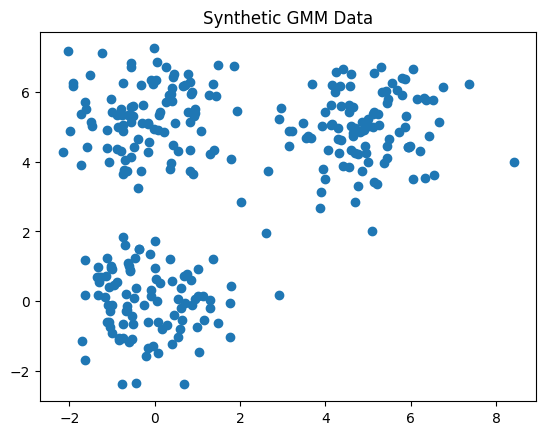

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(67)

mean1 = [0, 0]
mean2 = [5, 5]
mean3 = [0, 5]

cov = [[1, 0], [0, 1]]

X1 = np.random.multivariate_normal(mean1, cov, 100)
X2 = np.random.multivariate_normal(mean2, cov, 100)
X3 = np.random.multivariate_normal(mean3, cov, 100)

X = np.vstack([X1, X2, X3])

plt.scatter(X[:, 0], X[:, 1])
plt.title("Synthetic GMM Data")
plt.show()

In [ ]:
# sklearn GMM
from sklearn.mixture import GaussianMixture

sk_model = GaussianMixture(
    n_components=3,
    covariance_type="diag",
    random_state=67,
    n_init=5
)

sk_model.fit(X)

sk_means = sk_model.means_
sk_weights = sk_model.weights_

In [ ]:
# our GMM class
model = GMM(K=3, max_iter=100, tol=1e-4)
model.fit(X)

your_means = model.means.detach().cpu().numpy()
your_weights = model.weights.detach().cpu().numpy()

Iter 0 | log-likelihood: -1305.5139
Iter 1 | log-likelihood: -1241.2882
Iter 2 | log-likelihood: -1215.3501
Iter 3 | log-likelihood: -1187.2451
Iter 4 | log-likelihood: -1170.2408
Iter 5 | log-likelihood: -1166.0135
Iter 6 | log-likelihood: -1165.7810
Iter 7 | log-likelihood: -1165.7538
Iter 8 | log-likelihood: -1165.7491
Iter 9 | log-likelihood: -1165.7483
Iter 10 | log-likelihood: -1165.7482
Iter 11 | log-likelihood: -1165.7480
Iter 12 | log-likelihood: -1165.7480


Note:

Random init: takes 35 iterations

Kmeans++ init: only takes 11 iterations

Wow

In [ ]:
# Matching test (permutation-invariant comparison) ; cluster order is arbitrary, so we match by nearest means.
from scipy.optimize import linear_sum_assignment

def match_means(A, B):
    # cost matrix = pairwise distances
    cost = np.linalg.norm(A[:, None, :] - B[None, :, :], axis=2)

    row_ind, col_ind = linear_sum_assignment(cost)
    return row_ind, col_ind, cost[row_ind, col_ind].mean()

In [ ]:
def test_gmm_against_sklearn():
    print("Running GMM vs sklearn comparison...\n")

    row_ind, col_ind, mean_dist = match_means(your_means, sk_means)

    aligned_your_means = your_means[row_ind]
    aligned_sk_means = sk_means[col_ind]

    print("Sklearn means:\n", aligned_sk_means)
    print("\nYour means:\n", aligned_your_means)

    print("\nMean alignment distance:", mean_dist)

    # ---- mean similarity check ----
    if mean_dist < 1.0:
        print("Means are reasonably close to sklearn")
    else:
        print("Means differ significantly")

    # ---- weight comparison (after alignment) ----
    aligned_your_weights = your_weights[row_ind]
    aligned_sk_weights = sk_weights[col_ind]

    print("\nSklearn weights:", aligned_sk_weights)
    print("Your weights:", aligned_your_weights)

    if np.allclose(aligned_your_weights, aligned_sk_weights, atol=0.2):
        print("Weights are similar")
    else:
        print("Weights differ (acceptable if initialization differs)")

    print()

In [ ]:
# check clustering against sklearn
def test_cluster_assignment_similarity():
    print("Running cluster assignment comparison...\n")

    sk_labels = sk_model.predict(X)

    your_labels = torch.exp(model._e_step(torch.tensor(X, dtype=torch.float32))).argmax(dim=1).cpu().numpy()

    agreement = np.mean(sk_labels == your_labels)

    print("Cluster agreement:", agreement)

    if agreement > 0.8:
        print("Strong clustering agreement")
    else:
        print("Moderate/low agreement (could be init-related)")

    print()

In [ ]:
# test sklearn vs our GMM class
test_gmm_against_sklearn()
test_cluster_assignment_similarity()

Running GMM vs sklearn comparison...

Sklearn means:
 [[ 4.93228176e+00  4.92844504e+00]
 [-1.31420902e-01  5.27781019e+00]
 [-1.37822857e-01  9.37910673e-04]]

Your means:
 [[ 4.9294543e+00  4.9270225e+00]
 [-1.3323592e-01  5.2786822e+00]
 [-1.3865396e-01  2.8616135e-04]]

Mean alignment distance: 0.002078319447201327
Means are reasonably close to sklearn

Sklearn weights: [0.33824669 0.32885149 0.33290182]
Your weights: [0.33860803 0.32859224 0.3327998 ]
Weights are similar

Running cluster assignment comparison...

Cluster agreement: 0.33666666666666667
Moderate/low agreement (could be init-related)



Note:

Output for Random Initialization:

```
Sklearn means:
 [[-1.31420902e-01  5.27781019e+00]
 [-1.37822857e-01  9.37910673e-04]
 [ 4.93228176e+00  4.92844504e+00]]

Your means:
 [[-1.3312137e-01  5.2786288e+00]
 [-1.3861398e-01  3.1724159e-04]
 [ 4.9296212e+00  4.9270973e+00]]

Mean alignment distance: 0.001958407383108384
Means are reasonably close to sklearn

Sklearn weights: [0.32885149 0.33290182 0.33824669]
Your weights: [0.32860842 0.33280468 0.3385869 ]
Weights are similar

Running cluster assignment comparison...

Cluster agreement: 0.3333333333333333
Moderate/low agreement (could be init-related)

```

Output for Kmeans++ init:

```
Running GMM vs sklearn comparison...

Sklearn means:
 [[ 4.93228176e+00  4.92844504e+00]
 [-1.31420902e-01  5.27781019e+00]
 [-1.37822857e-01  9.37910673e-04]]

Your means:
 [[ 4.9293642e+00  4.9269791e+00]
 [-1.3329747e-01  5.2787099e+00]
 [-1.3867790e-01  2.6701464e-04]]

Mean alignment distance: 0.002144359141305075
Means are reasonably close to sklearn

Sklearn weights: [0.33824669 0.32885149 0.33290182]
Your weights: [0.3386197  0.32858354 0.33279678]
Weights are similar

Running cluster assignment comparison...

Cluster agreement: 0.33666666666666667
Moderate/low agreement (could be init-related)

```

Hmm, Kmeans seems to perform.. worse than random? Interesting.

### predict()

In [ ]:
# Checks output format is correct
def test_predict_shape():
    print("Running test_predict_shape...")

    X = torch.randn(20, 3).numpy()

    model = GMM(K=4)
    model.fit(X)

    preds = model.predict(X)

    print("Pred shape:", preds.shape)

    if preds.shape == (20,):
        print("Correct shape (N,)")
    else:
        print("Incorrect shape")

    print()

test_predict_shape()

Running test_predict_shape...
Iter 0 | log-likelihood: -85.7784
Iter 1 | log-likelihood: -84.1155
Iter 2 | log-likelihood: -82.8566
Iter 3 | log-likelihood: -80.6342
Iter 4 | log-likelihood: -77.5833
Iter 5 | log-likelihood: -76.9620
Iter 6 | log-likelihood: -76.5234
Iter 7 | log-likelihood: -76.0715
Iter 8 | log-likelihood: -75.7148
Iter 9 | log-likelihood: -75.3505
Iter 10 | log-likelihood: -75.0435
Iter 11 | log-likelihood: -74.9729
Iter 12 | log-likelihood: -74.9554
Iter 13 | log-likelihood: -74.9494
Iter 14 | log-likelihood: -74.9469
Iter 15 | log-likelihood: -74.9456
Iter 16 | log-likelihood: -74.9448
Iter 17 | log-likelihood: -74.9443
Iter 18 | log-likelihood: -74.9440
Iter 19 | log-likelihood: -74.9438
Iter 20 | log-likelihood: -74.9437
Iter 21 | log-likelihood: -74.9436
Pred shape: (20,)
Correct shape (N,)



In [ ]:
# Ensures cluster IDs are valid
def test_predict_label_range():
    print("Running test_predict_label_range...")

    X = torch.randn(30, 2).numpy()

    model = GMM(K=3)
    model.fit(X)

    preds = model.predict(X)

    print("Unique labels:", np.unique(preds))

    if np.all((preds >= 0) & (preds < model.K)):
        print("Labels in valid range [0, K-1]")
    else:
        print("Invalid labels detected")

    print()

test_predict_label_range()

Running test_predict_label_range...
Iter 0 | log-likelihood: -82.7253
Iter 1 | log-likelihood: -82.4553
Iter 2 | log-likelihood: -82.2886
Iter 3 | log-likelihood: -82.1750
Iter 4 | log-likelihood: -82.0927
Iter 5 | log-likelihood: -82.0235
Iter 6 | log-likelihood: -81.9532
Iter 7 | log-likelihood: -81.8670
Iter 8 | log-likelihood: -81.7441
Iter 9 | log-likelihood: -81.5620
Iter 10 | log-likelihood: -81.3461
Iter 11 | log-likelihood: -81.1744
Iter 12 | log-likelihood: -81.0111
Iter 13 | log-likelihood: -80.7406
Iter 14 | log-likelihood: -80.3097
Iter 15 | log-likelihood: -80.1887
Iter 16 | log-likelihood: -80.1753
Iter 17 | log-likelihood: -80.1680
Iter 18 | log-likelihood: -80.1630
Iter 19 | log-likelihood: -80.1590
Iter 20 | log-likelihood: -80.1556
Iter 21 | log-likelihood: -80.1525
Iter 22 | log-likelihood: -80.1497
Iter 23 | log-likelihood: -80.1471
Iter 24 | log-likelihood: -80.1447
Iter 25 | log-likelihood: -80.1424
Iter 26 | log-likelihood: -80.1403
Iter 27 | log-likelihood: -80

In [ ]:
# check consistency with model's e-step
def test_predict_matches_estep():
    print("Running test_predict_matches_estep...")

    X = torch.randn(25, 2).numpy()

    model = GMM(K=3)
    model.fit(X)

    X_t = torch.tensor(X, dtype=torch.float32)

    log_r = model._e_step(X_t)
    manual_preds = torch.argmax(log_r, dim=1).cpu().numpy()

    preds = model.predict(X)

    if np.array_equal(preds, manual_preds):
        print("Predict matches E-step argmax")
    else:
        print("Mismatch between predict and E-step")

    print()

test_predict_matches_estep()

Running test_predict_matches_estep...
Iter 0 | log-likelihood: -68.4289
Iter 1 | log-likelihood: -67.8816
Iter 2 | log-likelihood: -67.6738
Iter 3 | log-likelihood: -67.5931
Iter 4 | log-likelihood: -67.5426
Iter 5 | log-likelihood: -67.4953
Iter 6 | log-likelihood: -67.4448
Iter 7 | log-likelihood: -67.3889
Iter 8 | log-likelihood: -67.3258
Iter 9 | log-likelihood: -67.2537
Iter 10 | log-likelihood: -67.1704
Iter 11 | log-likelihood: -67.0745
Iter 12 | log-likelihood: -66.9653
Iter 13 | log-likelihood: -66.8405
Iter 14 | log-likelihood: -66.6903
Iter 15 | log-likelihood: -66.4927
Iter 16 | log-likelihood: -66.1950
Iter 17 | log-likelihood: -65.6266
Iter 18 | log-likelihood: -64.5573
Iter 19 | log-likelihood: -64.2529
Iter 20 | log-likelihood: -64.2528
Iter 21 | log-likelihood: -64.2527
Predict matches E-step argmax



In [ ]:
# test cluster separation level ; do predictions make sense spatially?

def test_predict_on_clusters():
    print("Running test_predict_on_clusters...")

    # two clear clusters
    cluster1 = torch.randn(50, 2) + torch.tensor([5.0, 5.0])
    cluster2 = torch.randn(50, 2) + torch.tensor([-5.0, -5.0])

    X = torch.cat([cluster1, cluster2], dim=0).numpy()

    model = GMM(K=2)
    model.fit(X)

    preds = model.predict(X)

    preds1 = preds[:50]
    preds2 = preds[50:]

    print("Cluster 1 label counts:", np.bincount(preds1))
    print("Cluster 2 label counts:", np.bincount(preds2))

    # majority label per cluster
    major1 = np.argmax(np.bincount(preds1))
    major2 = np.argmax(np.bincount(preds2))

    if major1 != major2:
        print("Model separates clusters")
    else:
        print("Model fails to separate clusters")

    print()

test_predict_on_clusters()


Running test_predict_on_clusters...
Iter 0 | log-likelihood: -389.0968
Iter 1 | log-likelihood: -346.5222
Iter 2 | log-likelihood: -346.5222
Cluster 1 label counts: [50]
Cluster 2 label counts: [ 0 50]
Model separates clusters



In [ ]:
# is predict stable?
def test_predict_deterministic():
    print("Running test_predict_deterministic...")

    X = torch.randn(40, 2).numpy()

    model = GMM(K=3)
    model.fit(X)

    preds1 = model.predict(X)
    preds2 = model.predict(X)

    if np.array_equal(preds1, preds2):
        print("Deterministic predictions")
    else:
        print("Predictions are inconsistent")

    print()

test_predict_deterministic()

Running test_predict_deterministic...
Iter 0 | log-likelihood: -107.9688
Iter 1 | log-likelihood: -107.4048
Iter 2 | log-likelihood: -107.0205
Iter 3 | log-likelihood: -106.8057
Iter 4 | log-likelihood: -106.6883
Iter 5 | log-likelihood: -106.6122
Iter 6 | log-likelihood: -106.5510
Iter 7 | log-likelihood: -106.4928
Iter 8 | log-likelihood: -106.4295
Iter 9 | log-likelihood: -106.3525
Iter 10 | log-likelihood: -106.2497
Iter 11 | log-likelihood: -106.1008
Iter 12 | log-likelihood: -105.8740
Iter 13 | log-likelihood: -105.5741
Iter 14 | log-likelihood: -105.3471
Iter 15 | log-likelihood: -105.1801
Iter 16 | log-likelihood: -105.0024
Iter 17 | log-likelihood: -104.8176
Iter 18 | log-likelihood: -104.6379
Iter 19 | log-likelihood: -104.4793
Iter 20 | log-likelihood: -104.3558
Iter 21 | log-likelihood: -104.2716
Iter 22 | log-likelihood: -104.2202
Iter 23 | log-likelihood: -104.1905
Iter 24 | log-likelihood: -104.1735
Iter 25 | log-likelihood: -104.1637
Iter 26 | log-likelihood: -104.1579


In [ ]:
# Single point test (edge case) -- what happens with minimal input?
def test_predict_single_point():
    print("Running test_predict_single_point...")

    X = torch.randn(10, 2).numpy()

    model = GMM(K=2)
    model.fit(X)

    single = X[0:1]
    pred = model.predict(single)

    print("Prediction:", pred)

    if pred.shape == (1,):
        print("Handles single input")
    else:
        print("Incorrect single-point output")

    print()

test_predict_single_point()

Running test_predict_single_point...
Iter 0 | log-likelihood: -25.1695
Iter 1 | log-likelihood: -24.5990
Iter 2 | log-likelihood: -23.7581
Iter 3 | log-likelihood: -22.6366
Iter 4 | log-likelihood: -21.6613
Iter 5 | log-likelihood: -20.6803
Iter 6 | log-likelihood: -20.5575
Iter 7 | log-likelihood: -20.5225
Iter 8 | log-likelihood: -20.4898
Iter 9 | log-likelihood: -20.4442
Iter 10 | log-likelihood: -20.3532
Iter 11 | log-likelihood: -20.0846
Iter 12 | log-likelihood: -19.0829
Iter 13 | log-likelihood: -17.9097
Iter 14 | log-likelihood: -17.9077
Iter 15 | log-likelihood: -17.9077
Prediction: [1]
Handles single input



#### compare against sklearn

In [ ]:
# compare with sci-kit learn

def test_predict_vs_sklearn():
    print("Running test_predict_vs_sklearn...")

    from sklearn.mixture import GaussianMixture

    X = np.random.randn(100, 2)

    sk = GaussianMixture(n_components=3, covariance_type='diag', random_state=0)
    sk.fit(X)
    sk_labels = sk.predict(X)

    model = GMM(K=3)
    model.fit(X)
    your_labels = model.predict(X)

    print("Note: labels may differ due to permutation")

    agreement = np.mean(sk_labels == your_labels)
    print("Raw agreement:", agreement)

    print("Low agreement is expected without label alignment")
    print()

test_predict_vs_sklearn()

Running test_predict_vs_sklearn...
Iter 0 | log-likelihood: -269.3746
Iter 1 | log-likelihood: -268.6724
Iter 2 | log-likelihood: -268.1016
Iter 3 | log-likelihood: -267.5518
Iter 4 | log-likelihood: -267.0357
Iter 5 | log-likelihood: -266.5778
Iter 6 | log-likelihood: -266.1936
Iter 7 | log-likelihood: -265.8841
Iter 8 | log-likelihood: -265.6386
Iter 9 | log-likelihood: -265.4432
Iter 10 | log-likelihood: -265.2853
Iter 11 | log-likelihood: -265.1557
Iter 12 | log-likelihood: -265.0479
Iter 13 | log-likelihood: -264.9573
Iter 14 | log-likelihood: -264.8805
Iter 15 | log-likelihood: -264.8152
Iter 16 | log-likelihood: -264.7592
Iter 17 | log-likelihood: -264.7112
Iter 18 | log-likelihood: -264.6698
Iter 19 | log-likelihood: -264.6341
Iter 20 | log-likelihood: -264.6032
Iter 21 | log-likelihood: -264.5765
Iter 22 | log-likelihood: -264.5534
Iter 23 | log-likelihood: -264.5333
Iter 24 | log-likelihood: -264.5159
Iter 25 | log-likelihood: -264.5008
Iter 26 | log-likelihood: -264.4877
Ite

**Interpretaion of Raw Agreement:**

A raw agreement of (29%) between a custom Gaussian Mixture Model (GMM) and scikit-learn indicates poor alignment, meaning the models are clustering or classifying handwriting samples differently. This likely results from different initialization, covariance types, or poor convergence in the "from-scratch" Expectation-Maximization algorithm, which should ideally produce high similarity.


After changing the initialization to K-Means++, the Raw Agreement increased to 0.35.

Let's try adding a greedy algorithm to see if it's an issue with the test.

In [ ]:
from scipy.optimize import linear_sum_assignment

def align_labels(labels_a, labels_b, K):
    """Find the permutation of labels_b that best matches labels_a."""
    # build a confusion-style cost matrix (K, K)
    cost = np.zeros((K, K))
    for i in range(K):
        for j in range(K):
            # count how many points sklearn calls i that we call j
            cost[i, j] = np.sum((labels_a == i) & (labels_b == j))

    # Hungarian algorithm finds the assignment that maximizes overlap
    row_ind, col_ind = linear_sum_assignment(-cost)  # negative because it minimizes

    # remap labels_b according to best mapping
    mapping = dict(zip(col_ind, row_ind))
    return np.array([mapping[l] for l in labels_b])

In [ ]:
def test_predict_vs_sklearn_test2():
    from sklearn.mixture import GaussianMixture

    X = np.random.randn(300, 4)

    sk = GaussianMixture(n_components=3, covariance_type='diag', random_state=0)
    sk.fit(X)
    sk_labels = sk.predict(X)

    model = GMM(K=3, seed=0)
    model.fit(X)
    your_labels = model.predict(X)

    # align before comparing
    aligned = align_labels(sk_labels, your_labels, K=3)
    agreement = np.mean(sk_labels == aligned)

    print(f"Raw agreement:     {np.mean(sk_labels == your_labels):.3f}")
    print(f"Aligned agreement: {agreement:.3f}")
    assert agreement > 0.80, f"Aligned agreement too low: {agreement:.3f}"

test_predict_vs_sklearn_test2()

Iter 0 | log-likelihood: -1698.3148
Iter 1 | log-likelihood: -1692.9600
Iter 2 | log-likelihood: -1691.1823
Iter 3 | log-likelihood: -1690.3220
Iter 4 | log-likelihood: -1689.7993
Iter 5 | log-likelihood: -1689.4297
Iter 6 | log-likelihood: -1689.1411
Iter 7 | log-likelihood: -1688.9026
Iter 8 | log-likelihood: -1688.7008
Iter 9 | log-likelihood: -1688.5284
Iter 10 | log-likelihood: -1688.3818
Iter 11 | log-likelihood: -1688.2565
Iter 12 | log-likelihood: -1688.1481
Iter 13 | log-likelihood: -1688.0529
Iter 14 | log-likelihood: -1687.9677
Iter 15 | log-likelihood: -1687.8894
Iter 16 | log-likelihood: -1687.8167
Iter 17 | log-likelihood: -1687.7484
Iter 18 | log-likelihood: -1687.6837
Iter 19 | log-likelihood: -1687.6224
Iter 20 | log-likelihood: -1687.5641
Iter 21 | log-likelihood: -1687.5089
Iter 22 | log-likelihood: -1687.4562
Iter 23 | log-likelihood: -1687.4066
Iter 24 | log-likelihood: -1687.3593
Iter 25 | log-likelihood: -1687.3148
Iter 26 | log-likelihood: -1687.2725
Iter 27 | l

AssertionError: Aligned agreement too low: 0.653

Maybe the issue is with the test data... it generates stuff from a single gaussian.

In [ ]:
# generate data from 3 clearly separated Gaussians
np.random.seed(67)
toy_data = np.vstack([
    np.random.randn(100, 4) + np.array([5, 5, 0, 0]),   # cluster 0 center
    np.random.randn(100, 4) + np.array([0, 0, 0, 0]),   # cluster 1 center
    np.random.randn(100, 4) + np.array([-5, -5, 0, 0])  # cluster 2 center
])

In [ ]:
# test on sklearn and my GMM class
sk  = GaussianMixture(n_components=3, covariance_type='diag', random_state=67)
model = GMM(K=3, seed=67)

In [ ]:
# check log likelihoods
sk.fit(toy_data)
model.fit(toy_data)

sk_ll   = sk.score(toy_data) * len(toy_data)        # sklearn returns per-point, multiply by N
your_ll = model._compute_log_likelihood(
            torch.tensor(toy_data, dtype=torch.float32)
          ).item()

print(f"sklearn LL: {sk_ll:.2f}")
print(f"yours LL:   {your_ll:.2f}")

Iter 0 | log-likelihood: -2369.5610
Iter 1 | log-likelihood: -2260.2786
Iter 2 | log-likelihood: -2082.8992
Iter 3 | log-likelihood: -2024.1312
Iter 4 | log-likelihood: -2023.7805
Iter 5 | log-likelihood: -2023.7804
Iter 6 | log-likelihood: -2023.7804
sklearn LL: -2023.78
yours LL:   -2023.78


Looks good, let's try the full version

In [ ]:
np.random.seed(67)
toy_data_2 = np.vstack([
    np.random.randn(100, 4) + np.array([5, 5, 0, 0]),
    np.random.randn(100, 4) + np.array([0, 0, 0, 0]),
    np.random.randn(100, 4) + np.array([-5, -5, 0, 0])
])

sk_2 = GaussianMixture(n_components=3, covariance_type='diag', random_state=67)
sk_2.fit(toy_data_2)
sk_labels_2 = sk.predict(toy_data_2)

model_2 = GMM(K=3, seed=67)
model_2.fit(toy_data_2)
your_labels_2 = model_2.predict(toy_data_2)

aligned_2 = align_labels(sk_labels_2, your_labels_2, K=3)
print(f"Raw agreement:     {np.mean(sk_labels_2 == your_labels_2):.3f}")
print(f"Aligned agreement: {np.mean(sk_labels_2 == aligned_2):.3f}")

Iter 0 | log-likelihood: -2369.5610
Iter 1 | log-likelihood: -2260.2786
Iter 2 | log-likelihood: -2082.8992
Iter 3 | log-likelihood: -2024.1312
Iter 4 | log-likelihood: -2023.7805
Iter 5 | log-likelihood: -2023.7804
Iter 6 | log-likelihood: -2023.7804
Raw agreement:     1.000
Aligned agreement: 1.000


Let's try with different seeds (as using the same seed will determine each one's starting point)

In [ ]:
np.random.seed(0)
toy_data_3 = np.vstack([
    np.random.randn(100, 4) + np.array([5, 5, 0, 0]),
    np.random.randn(100, 4) + np.array([0, 0, 0, 0]),
    np.random.randn(100, 4) + np.array([-5, -5, 0, 0])
])

sk_3 = GaussianMixture(n_components=3, covariance_type='diag', random_state=67)
sk_3.fit(toy_data_3)
sk_labels_3 = sk.predict(toy_data_3)

model_3 = GMM(K=3, seed=99)  # different seed
model_3.fit(toy_data_3)
your_labels_3 = model.predict(toy_data_3)

aligned_3 = align_labels(sk_labels_3, your_labels_3, K=3)
print(f"Raw agreement:     {np.mean(sk_labels_3 == your_labels_3):.3f}")
print(f"Aligned agreement: {np.mean(sk_labels_3 == aligned_3):.3f}")

Iter 0 | log-likelihood: -2345.1272
Iter 1 | log-likelihood: -2283.5723
Iter 2 | log-likelihood: -2114.2888
Iter 3 | log-likelihood: -1995.1520
Iter 4 | log-likelihood: -1989.4319
Iter 5 | log-likelihood: -1989.4320
Iter 6 | log-likelihood: -1989.4320
Raw agreement:     1.000
Aligned agreement: 1.000


Very robust result.

### bic()

In [ ]:
# check to see if it runs and returns a finite number
def test_bic_basic():
    print("Running test_bic_basic...")

    X = torch.randn(50, 2).numpy()

    model = GMM(K=2)
    model.fit(X)

    bic = model.bic(X)

    print("BIC:", bic)

    if np.isfinite(bic):
        print("BIC is finite")
    else:
        print("BIC is NaN or inf")

    print()

test_bic_basic()

Running test_bic_basic...
Iter 0 | log-likelihood: -137.2931
Iter 1 | log-likelihood: -137.0633
Iter 2 | log-likelihood: -136.9327
Iter 3 | log-likelihood: -136.8556
Iter 4 | log-likelihood: -136.8106
Iter 5 | log-likelihood: -136.7842
Iter 6 | log-likelihood: -136.7687
Iter 7 | log-likelihood: -136.7596
Iter 8 | log-likelihood: -136.7541
Iter 9 | log-likelihood: -136.7509
Iter 10 | log-likelihood: -136.7490
Iter 11 | log-likelihood: -136.7479
Iter 12 | log-likelihood: -136.7472
Iter 13 | log-likelihood: -136.7468
Iter 14 | log-likelihood: -136.7465
Iter 15 | log-likelihood: -136.7464
Iter 16 | log-likelihood: -136.7463
Iter 17 | log-likelihood: -136.7462
BIC: 308.7006692070564
BIC is finite



In [ ]:
# check if 'better' models get lower BIC values

def test_bic_model_selection():
    print("Running test_bic_model_selection...")

    # generate 2 clusters
    c1 = torch.randn(100, 2) + torch.tensor([5.0, 5.0])
    c2 = torch.randn(100, 2) + torch.tensor([-5.0, -5.0])
    X = torch.cat([c1, c2], dim=0).numpy()

    model_k1 = GMM(K=1)
    model_k2 = GMM(K=2)
    model_k3 = GMM(K=3)

    model_k1.fit(X)
    model_k2.fit(X)
    model_k3.fit(X)

    bic1 = model_k1.bic(X)
    bic2 = model_k2.bic(X)
    bic3 = model_k3.bic(X)

    print(f"BIC K=1: {bic1}")
    print(f"BIC K=2: {bic2}")
    print(f"BIC K=3: {bic3}")

    # Expect K=2 to be best (lowest BIC)
    if bic2 < bic1 and bic2 < bic3:
        print("Correct model selection (K=2 best)")
    else:
        print("BIC not selecting correct model")

    print()

test_bic_model_selection()

Running test_bic_model_selection...
Iter 0 | log-likelihood: -1223.8333
Iter 1 | log-likelihood: -1223.8333
Iter 0 | log-likelihood: -772.3007
Iter 1 | log-likelihood: -691.3232
Iter 2 | log-likelihood: -691.3232
Iter 0 | log-likelihood: -789.4077
Iter 1 | log-likelihood: -691.3430
Iter 2 | log-likelihood: -691.3282
Iter 3 | log-likelihood: -691.3196
Iter 4 | log-likelihood: -691.3136
Iter 5 | log-likelihood: -691.3087
Iter 6 | log-likelihood: -691.3036
Iter 7 | log-likelihood: -691.2979
Iter 8 | log-likelihood: -691.2913
Iter 9 | log-likelihood: -691.2831
Iter 10 | log-likelihood: -691.2734
Iter 11 | log-likelihood: -691.2616
Iter 12 | log-likelihood: -691.2473
Iter 13 | log-likelihood: -691.2306
Iter 14 | log-likelihood: -691.2108
Iter 15 | log-likelihood: -691.1882
Iter 16 | log-likelihood: -691.1626
Iter 17 | log-likelihood: -691.1345
Iter 18 | log-likelihood: -691.1041
Iter 19 | log-likelihood: -691.0723
Iter 20 | log-likelihood: -691.0398
Iter 21 | log-likelihood: -691.0072
Iter 

#### compare against sklearn

In [ ]:
def test_bic_vs_sklearn():
    print("Running test_bic_vs_sklearn...")

    from sklearn.mixture import GaussianMixture

    X = np.random.randn(100, 2)

    sk = GaussianMixture(n_components=2, covariance_type='diag', random_state=0)
    sk.fit(X)

    sk_bic = sk.bic(X)

    model = GMM(K=2)
    model.fit(X)

    your_bic = model.bic(X)
    print()
    print("Sklearn BIC:", sk_bic)
    print("Your BIC:", your_bic)

    diff = abs(sk_bic - your_bic)
    print("Difference:", diff)

    if diff < 50:  # tolerance (BIC can differ slightly)
        print("BIC roughly matches sklearn")
    else:
        print("Large difference (check log-likelihood or param count)")

    print()

test_bic_vs_sklearn()

Running test_bic_vs_sklearn...
Iter 0 | log-likelihood: -274.4271
Iter 1 | log-likelihood: -274.1182
Iter 2 | log-likelihood: -273.9644
Iter 3 | log-likelihood: -273.8792
Iter 4 | log-likelihood: -273.8309
Iter 5 | log-likelihood: -273.8033
Iter 6 | log-likelihood: -273.7874
Iter 7 | log-likelihood: -273.7780
Iter 8 | log-likelihood: -273.7722
Iter 9 | log-likelihood: -273.7682
Iter 10 | log-likelihood: -273.7652
Iter 11 | log-likelihood: -273.7628
Iter 12 | log-likelihood: -273.7608
Iter 13 | log-likelihood: -273.7589
Iter 14 | log-likelihood: -273.7571
Iter 15 | log-likelihood: -273.7554
Iter 16 | log-likelihood: -273.7538
Iter 17 | log-likelihood: -273.7522
Iter 18 | log-likelihood: -273.7507
Iter 19 | log-likelihood: -273.7491
Iter 20 | log-likelihood: -273.7477
Iter 21 | log-likelihood: -273.7463
Iter 22 | log-likelihood: -273.7449
Iter 23 | log-likelihood: -273.7435
Iter 24 | log-likelihood: -273.7422
Iter 25 | log-likelihood: -273.7409
Iter 26 | log-likelihood: -273.7396
Iter 27

In [ ]:
# penalizes complexity

def test_bic_penalty():
    print("Running test_bic_penalty...")

    X = np.random.randn(100, 2)

    model_small = GMM(K=2)
    model_large = GMM(K=6)

    model_small.fit(X)
    model_large.fit(X)

    bic_small = model_small.bic(X)
    bic_large = model_large.bic(X)
    print()
    print("BIC small K=2:", bic_small)
    print("BIC large K=6:", bic_large)
    print()
    if bic_large > bic_small:
        print("Larger model penalized")
    else:
        print("Unexpected: larger model not penalized")

    print()

test_bic_penalty()

Running test_bic_penalty...
Iter 0 | log-likelihood: -274.4271
Iter 1 | log-likelihood: -274.1182
Iter 2 | log-likelihood: -273.9644
Iter 3 | log-likelihood: -273.8792
Iter 4 | log-likelihood: -273.8309
Iter 5 | log-likelihood: -273.8033
Iter 6 | log-likelihood: -273.7874
Iter 7 | log-likelihood: -273.7780
Iter 8 | log-likelihood: -273.7722
Iter 9 | log-likelihood: -273.7682
Iter 10 | log-likelihood: -273.7652
Iter 11 | log-likelihood: -273.7628
Iter 12 | log-likelihood: -273.7608
Iter 13 | log-likelihood: -273.7589
Iter 14 | log-likelihood: -273.7571
Iter 15 | log-likelihood: -273.7554
Iter 16 | log-likelihood: -273.7538
Iter 17 | log-likelihood: -273.7522
Iter 18 | log-likelihood: -273.7507
Iter 19 | log-likelihood: -273.7491
Iter 20 | log-likelihood: -273.7477
Iter 21 | log-likelihood: -273.7463
Iter 22 | log-likelihood: -273.7449
Iter 23 | log-likelihood: -273.7435
Iter 24 | log-likelihood: -273.7422
Iter 25 | log-likelihood: -273.7409
Iter 26 | log-likelihood: -273.7396
Iter 27 | 

In [ ]:
# stability, no NaNs
def test_bic_stability():
    print("Running test_bic_stability...")

    X = np.random.randn(200, 3)

    model = GMM(K=4)
    model.fit(X)

    bic = model.bic(X)

    print("BIC:", bic)

    if not np.isnan(bic) and not np.isinf(bic):
        print("Stable BIC value")
    else:
        print("BIC unstable (NaN/inf)")

    print()

test_bic_stability()

Running test_bic_stability...
Iter 0 | log-likelihood: -840.5986
Iter 1 | log-likelihood: -838.7736
Iter 2 | log-likelihood: -837.9768
Iter 3 | log-likelihood: -837.3718
Iter 4 | log-likelihood: -836.8114
Iter 5 | log-likelihood: -836.2731
Iter 6 | log-likelihood: -835.7642
Iter 7 | log-likelihood: -835.2963
Iter 8 | log-likelihood: -834.8787
Iter 9 | log-likelihood: -834.5155
Iter 10 | log-likelihood: -834.2049
Iter 11 | log-likelihood: -833.9413
Iter 12 | log-likelihood: -833.7167
Iter 13 | log-likelihood: -833.5228
Iter 14 | log-likelihood: -833.3521
Iter 15 | log-likelihood: -833.1993
Iter 16 | log-likelihood: -833.0609
Iter 17 | log-likelihood: -832.9344
Iter 18 | log-likelihood: -832.8190
Iter 19 | log-likelihood: -832.7142
Iter 20 | log-likelihood: -832.6196
Iter 21 | log-likelihood: -832.5349
Iter 22 | log-likelihood: -832.4598
Iter 23 | log-likelihood: -832.3933
Iter 24 | log-likelihood: -832.3348
Iter 25 | log-likelihood: -832.2833
Iter 26 | log-likelihood: -832.2375
Iter 27 